# SDO Temporal Forecasting — Inference & Visualizzazione

Notebook per eseguire inferenza sul test set (2023-2025) e visualizzare i risultati del modello `MAE_TemporalForecaster`.

Il modello riceve un'immagine a 9 canali al tempo **t** e predice l'immagine al tempo **t + Δt**.

## 0. Configurazione

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, Subset

# ─── PATHS — modifica qui ───────────────────────────────────────────────────
MAE_CHECKPOINT   = '/home/gpatane/SDO_downstream/mae_project/checkpoints/ch9_1024_p8_normpix/best_model.pth'
FORECAST_CKPT    = '/home/gpatane/SDO_downstream/forecast_project/checkpoints/frozen_normpix_new_ultimate_p8_tb6_dd8_24h_best.pth'
#FORECAST_CKPT    = '/home/gpatane/SDO_downstream/forecast_project/checkpoints/frozen_normpix_tb6_dd8_best.pth'
DEVICE           = 'cuda:0' if torch.cuda.is_available() else 'cpu'
TARGET_SIZE      = 1024
BATCH_SIZE       = 1          # tieni a 1 per comodità di visualizzazione
N_SHOW           = 5          # campioni da mostrare nella gallery
DELTA_T_H        = [24]       # deve corrispondere a quello usato in training

# Iperparametri architettura (devono coincidere col checkpoint)
NUM_TEMPORAL_BLOCKS = 6
DECODER_DEPTH       = 8

WAVELENGTHS = ['94Å','131Å','171Å','193Å','211Å','304Å','335Å','1600Å','1700Å']
# colormap per ogni lunghezza d'onda AIA (sunpy)
AIA_CMAPS   = ['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211',
                'sdoaia304','sdoaia335','sdoaia1600','sdoaia1700']

TEST_YEARS = list(range(2023, 2026))

print(f'Device  : {DEVICE}')
print(f'Ckpt    : {FORECAST_CKPT}')

Device  : cuda:0
Ckpt    : /home/gpatane/SDO_downstream/forecast_project/checkpoints/frozen_normpix_new_ultimate_p8_tb6_dd8_24h_best.pth


## 1. Dataset

In [2]:
from dataset import SDO_TemporalDataset, WAVELENGTHS_9, ZARR_PATH

test_ds = SDO_TemporalDataset(
    zarr_path=ZARR_PATH,
    list_year=TEST_YEARS,
    wavelengths=WAVELENGTHS_9,
    target_size=TARGET_SIZE,
    delta_t_hours=DELTA_T_H,
    max_gap_hours=3.0,
)
print(f'Zarr usato   : {ZARR_PATH}')
print(f'Coppie test  : {len(test_ds):,}')
print(f'  (src, tgt, Δt) esempio: {test_ds.pairs[0]}')

Zarr usato   : /home/gpatane/Dataset/zarr_file_magnetogram_1024_rechunked.zarr
Coppie test  : 1,918
  (src, tgt, Δt) esempio: (0, 2, 24)


## 2. Caricamento modello

In [3]:
from models import MAE_TemporalForecaster

device = torch.device(DEVICE)

model = MAE_TemporalForecaster(
    mae_checkpoint=MAE_CHECKPOINT,
    img_size=TARGET_SIZE,
    patch_size=8,
    in_chans=9,
    embed_dim=768,
    depth=12,
    num_heads=12,
    decoder_embed_dim=512,
    decoder_depth=DECODER_DEPTH,
    decoder_num_heads=16,
    num_temporal_blocks=NUM_TEMPORAL_BLOCKS,
    delta_t_values=DELTA_T_H,
    freeze_encoder=True,
    use_gradient_checkpointing=False,   # disabilita per inferenza
    device=str(device),
).to(device)

ckpt = torch.load(FORECAST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

epoch     = ckpt.get('epoch', '?')
best_loss = ckpt.get('best_val_loss', float('nan'))
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f'Checkpoint  : epoch={epoch}  best_val_loss={best_loss:.5f}')

/home/gpatane/miniconda3/envs/SDOenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checkpoint  : epoch=16  best_val_loss=0.00223


## 3. Funzioni di utilità

In [4]:
@torch.no_grad()
def predict(model, batch, device):
    """Esegue forward e ritorna pred, input, target come numpy [9,H,W]."""
    x       = batch['input'].to(device)
    tgt     = batch['target'].to(device)
    dt_idx  = batch['delta_t_idx'].to(device)
    pred    = model(x, dt_idx)
    return (
        pred[0].cpu().numpy(),
        x[0].cpu().numpy(),
        tgt[0].cpu().numpy(),
        float(batch['delta_t_h'][0]),
    )


def norm_ch(img):
    """Min-max su singolo canale 2D per visualizzazione."""
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-8)


def mse_ch(pred, tgt):
    """MSE per canale, ritorna array [9]."""
    return ((pred - tgt) ** 2).mean(axis=(1, 2))


def ssim_ch(pred, tgt, c1=0.01**2, c2=0.03**2):
    """SSIM semplificato per confronto rapido (senza filtro gaussiano)."""
    scores = []
    for c in range(pred.shape[0]):
        p, t = pred[c].ravel(), tgt[c].ravel()
        mu_p, mu_t = p.mean(), t.mean()
        sig_p  = p.var()
        sig_t  = t.var()
        sig_pt = ((p - mu_p) * (t - mu_t)).mean()
        num = (2*mu_p*mu_t + c1) * (2*sig_pt + c2)
        den = (mu_p**2 + mu_t**2 + c1) * (sig_p + sig_t + c2)
        scores.append(num / den)
    return np.array(scores)


print('Utility functions definite.')

Utility functions definite.


## 4. Gallery — N campioni casuali

Per ogni campione: **input** (t) | **predizione** (t+Δt) | **target reale** (t+Δt) | **errore pixel** per tutti i 9 canali.

In [ ]:
rng     = np.random.default_rng(42)
indices = rng.choice(len(test_ds), size=min(N_SHOW, len(test_ds)), replace=False).tolist()

all_mse  = []   # shape (N_SHOW, 9)
all_ssim = []

for sample_n, idx in enumerate(indices):
    batch = test_ds[idx]
    # aggiungi dimensione batch
    batch = {k: v.unsqueeze(0) for k, v in batch.items()}

    pred_np, inp_np, tgt_np, dt_h = predict(model, batch, device)

    mse  = mse_ch(pred_np, tgt_np)
    ssim = ssim_ch(pred_np, tgt_np)
    all_mse.append(mse)
    all_ssim.append(ssim)

    n_ch = pred_np.shape[0]
    # 4 righe: input / target / pred / errore
    fig, axes = plt.subplots(4, n_ch, figsize=(2.8 * n_ch, 11))
    row_labels = [f'Input  t', f'Target t+{int(dt_h)}h', f'Pred   t+{int(dt_h)}h', 'Errore |Pred−Tgt|']

    for c in range(n_ch):
        cmap = AIA_CMAPS[c]

        def show(ax, img, cmap, vmin=None, vmax=None):
            try:
                ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            except Exception:
                ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
            ax.axis('off')

        show(axes[0, c], norm_ch(inp_np[c]),  cmap)
        show(axes[1, c], norm_ch(tgt_np[c]),  cmap)
        show(axes[2, c], norm_ch(pred_np[c]), cmap)
        err = np.abs(pred_np[c] - tgt_np[c])
        show(axes[3, c], err, 'hot', vmin=0)

        axes[0, c].set_title(WAVELENGTHS[c], fontsize=8)
        axes[3, c].set_xlabel(f'MSE={mse[c]:.4f}\nSSIM={ssim[c]:.3f}', fontsize=7)

    for r, lbl in enumerate(row_labels):
        axes[r, 0].set_ylabel(lbl, fontsize=9, rotation=90, labelpad=4)

    fig.suptitle(
        f'Campione {idx}  |  Δt={int(dt_h)}h  |  '
        f'MSE medio={mse.mean():.5f}  SSIM medio={ssim.mean():.3f}',
        fontsize=11, y=1.005
    )
    plt.tight_layout()
    plt.show()
    print(f'  [{sample_n+1}/{N_SHOW}] idx={idx}  MSE={mse.mean():.5f}  SSIM={ssim.mean():.3f}')

all_mse  = np.array(all_mse)   # [N_SHOW, 9]
all_ssim = np.array(all_ssim)

## 5. Confronto affiancato per canale singolo
Zoom su un canale specifico per tutti i campioni visualizzati.

MSE loss: 0.005678
MSE loss: 0.004561
MSE loss: 0.006004
MSE loss: 0.005179
MSE loss: 0.004081


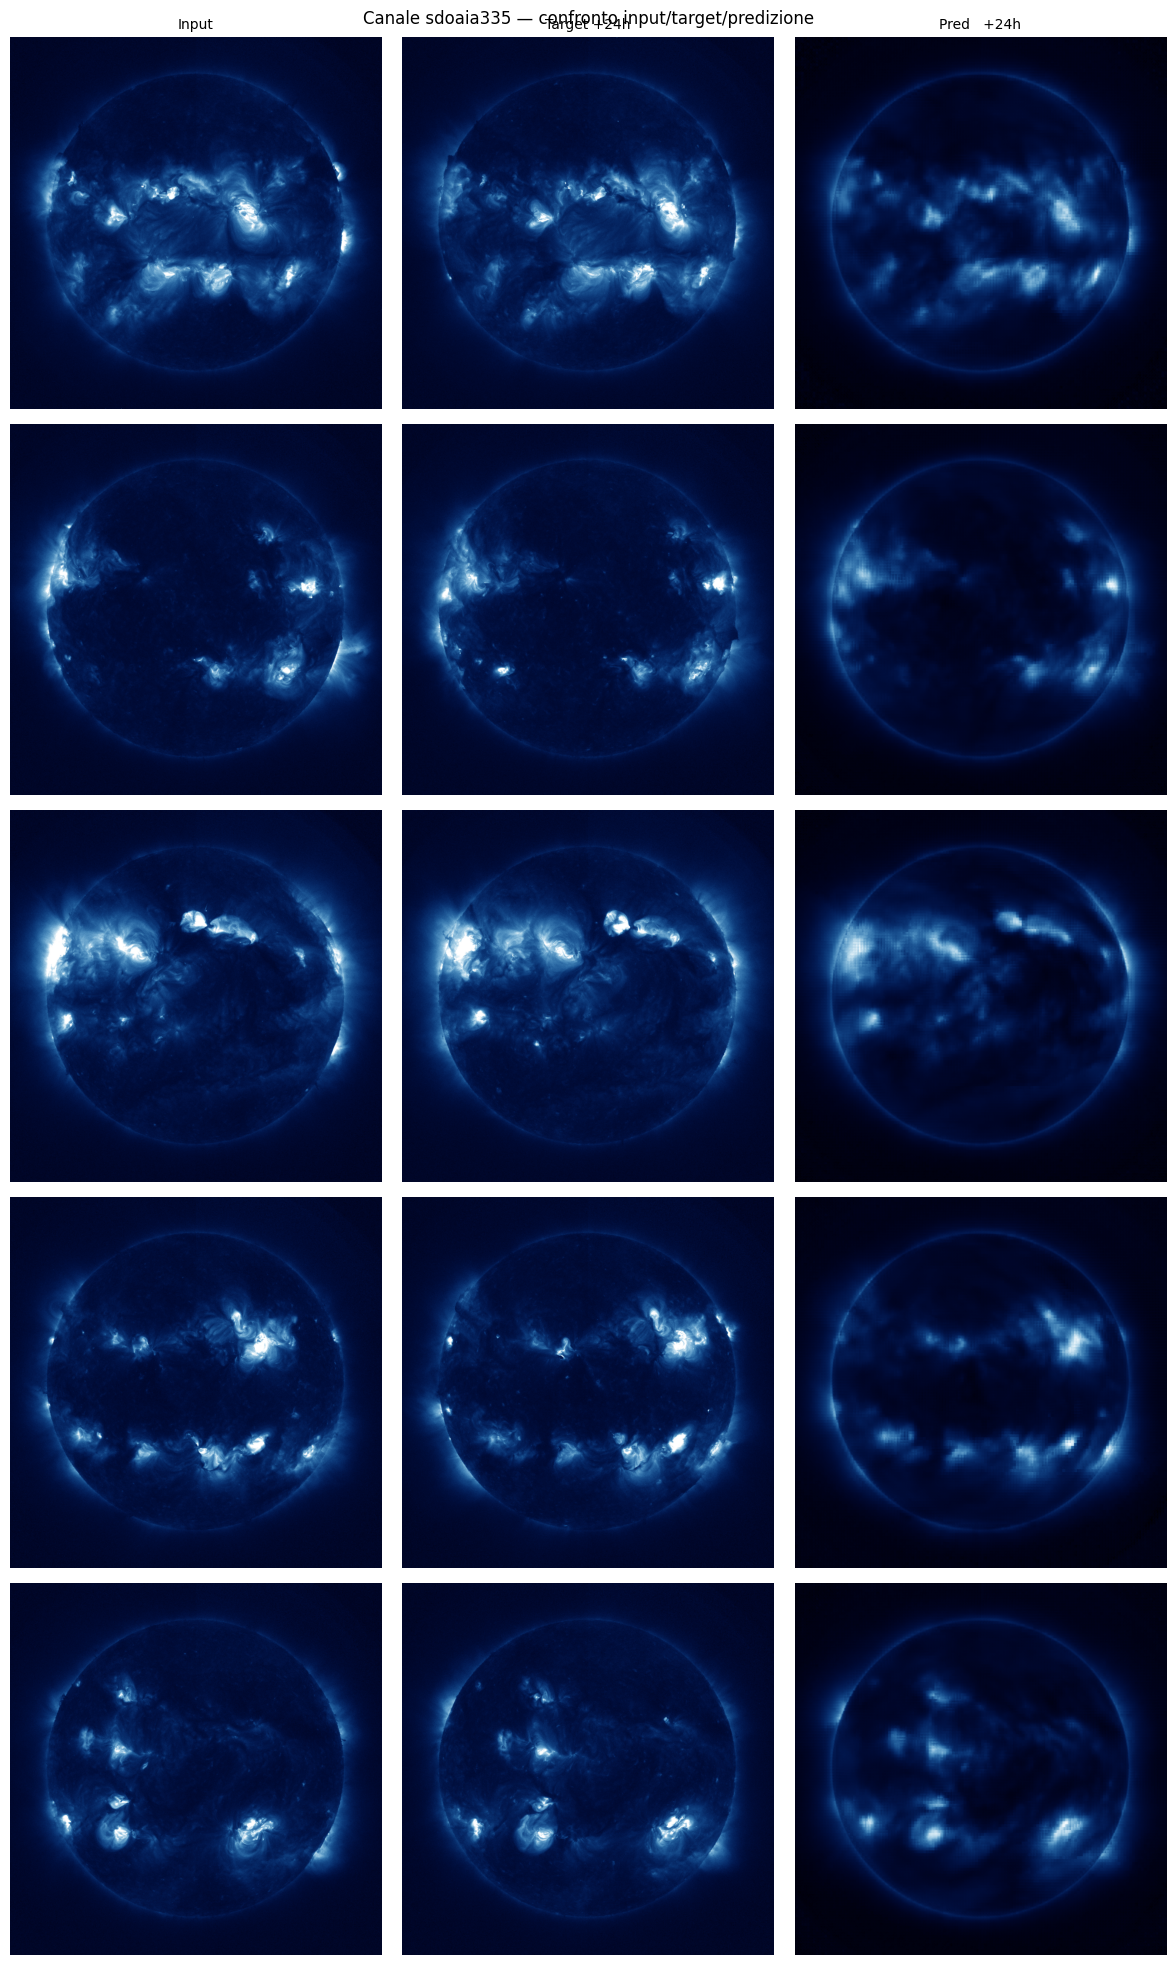

: 

In [ ]:
from sunpy.map import Map
WAVELENGTHS = ['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335','sdoaia1600','sdoaia1700']
CHANNEL_IDX = 6 # 0..8  — es. 2=171Å (corona calda)
rng     = np.random.default_rng(42)
indices = rng.choice(len(test_ds), size=min(N_SHOW, len(test_ds)), replace=False).tolist()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, 4 * N_SHOW))
col_titles = ['Input  t', f'Target t+Δt', f'Pred t+Δt']

for row, idx in enumerate(indices):
    batch = test_ds[idx]
    batch = {k: v.unsqueeze(0) for k, v in batch.items()}
    pred_np, inp_np, tgt_np, dt_h = predict(model, batch, device)

    with torch.no_grad():
        pred_tensor = torch.from_numpy(pred_np).unsqueeze(0).to(device)
        tgt_tensor = torch.from_numpy(tgt_np).unsqueeze(0).to(device)
        loss_normalized = model.compute_loss(pred_tensor, tgt_tensor, norm_pix=False,tv_weight=0.05)
        print(f"MSE loss: {loss_normalized.item():.6f}")
    cmap = AIA_CMAPS[CHANNEL_IDX]
    for col, (img, label) in enumerate([
        (inp_np[CHANNEL_IDX],  f'Input'),
        (tgt_np[CHANNEL_IDX],  f'Target +{int(dt_h)}h'),
        (pred_np[CHANNEL_IDX], f'Pred   +{int(dt_h)}h'),
    ]):
        ax = axes[row, col]
        try:
            ax.imshow(norm_ch(img), cmap=WAVELENGTHS[CHANNEL_IDX])
        except Exception:
            ax.imshow(norm_ch(img), cmap=WAVELENGTHS[CHANNEL_IDX])
        ax.axis('off')
        if row == 0:
            ax.set_title(label, fontsize=10)
    axes[row, 0].set_ylabel(f'idx {idx}', fontsize=8, rotation=90)

fig.suptitle(f'Canale {WAVELENGTHS[CHANNEL_IDX]} — confronto input/target/predizione', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Differenza spaziale: predizione vs target
Mappa degli errori (residui) per ogni canale su un singolo campione.

In [ ]:
SAMPLE_IDX = indices[0]   # scegli l'indice

batch = test_ds[SAMPLE_IDX]
batch = {k: v.unsqueeze(0) for k, v in batch.items()}
pred_np, inp_np, tgt_np, dt_h = predict(model, batch, device)

n_ch = pred_np.shape[0]
fig, axes = plt.subplots(1, n_ch, figsize=(3.0 * n_ch, 3.5))

vmax_global = np.abs(pred_np - tgt_np).max()

for c in range(n_ch):
    
    residual = pred_np[c] - tgt_np[c]
    im = axes[c].imshow(residual, cmap='RdBu_r',
                         vmin=-vmax_global, vmax=vmax_global)
    axes[c].set_title(WAVELENGTHS[c], fontsize=8)
    axes[c].axis('off')

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label='Pred − Target')
fig.suptitle(f'Residui (Pred − Target)  |  campione {SAMPLE_IDX}  Δt={int(dt_h)}h', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Valutazione su tutto il test set

In [ ]:
MAX_BATCHES = None   # None = tutto il test set; es. 100 per stima rapida

test_loader = DataLoader(test_ds, batch_size=2, shuffle=False,
                         num_workers=4, pin_memory=True)

model.eval()
mse_per_ch  = []   # lista di array [9]
ssim_per_ch = []
dt_list     = []

with torch.no_grad():
    for b_idx, batch in enumerate(test_loader):
        if MAX_BATCHES and b_idx >= MAX_BATCHES:
            break
        x      = batch['input'].to(device)
        tgt    = batch['target'].to(device)
        dt_idx = batch['delta_t_idx'].to(device)
        pred   = model(x, dt_idx)

        pred_np = pred.cpu().numpy()    # [B, 9, H, W]
        tgt_np  = tgt.cpu().numpy()

        for i in range(pred_np.shape[0]):
            mse_per_ch.append(mse_ch(pred_np[i], tgt_np[i]))
            ssim_per_ch.append(ssim_ch(pred_np[i], tgt_np[i]))
            dt_list.append(float(batch['delta_t_h'][i]))

        if (b_idx + 1) % 50 == 0:
            print(f'Batch {b_idx+1:4d} — MSE medio: {np.mean(mse_per_ch):.5f}')

mse_arr  = np.array(mse_per_ch)   # [N, 9]
ssim_arr = np.array(ssim_per_ch)
N_eval   = len(mse_arr)

print(f'\n{"="*55}')
print(f'Campioni valutati   : {N_eval:,}')
print(f'MSE globale (media) : {mse_arr.mean():.6f}')
print(f'SSIM globale (media): {ssim_arr.mean():.4f}')
print(f'{"─"*55}')
for c, wl in enumerate(WAVELENGTHS):
    print(f'  {wl:6s}  MSE={mse_arr[:,c].mean():.6f}  SSIM={ssim_arr[:,c].mean():.4f}')

## 8. Metriche per canale — barplot

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_mse  = mse_arr.mean(axis=0)
std_mse   = mse_arr.std(axis=0)
mean_ssim = ssim_arr.mean(axis=0)
std_ssim  = ssim_arr.std(axis=0)

x = np.arange(len(WAVELENGTHS))
w = 0.6

axes[0].bar(x, mean_mse, w, yerr=std_mse, capsize=4, color='steelblue', alpha=0.85, ecolor='gray')
axes[0].set_xticks(x); axes[0].set_xticklabels(WAVELENGTHS, rotation=30, ha='right')
axes[0].set_ylabel('MSE'); axes[0].set_title('MSE per canale')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, mean_ssim, w, yerr=std_ssim, capsize=4, color='darkorange', alpha=0.85, ecolor='gray')
axes[1].set_xticks(x); axes[1].set_xticklabels(WAVELENGTHS, rotation=30, ha='right')
axes[1].set_ylabel('SSIM'); axes[1].set_title('SSIM per canale')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(1.0, color='k', lw=0.8, ls='--', alpha=0.4)

fig.suptitle(f'Metriche test set  (N={N_eval:,}  Δt={DELTA_T_H[0]}h)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Distribuzione MSE (per canale)

In [ ]:
n_ch = len(WAVELENGTHS)
fig, axes = plt.subplots(3, 3, figsize=(13, 9))

for c, ax in enumerate(axes.ravel()):
    vals = mse_arr[:, c]
    ax.hist(vals, bins=40, color='steelblue', alpha=0.8, edgecolor='k', linewidth=0.4)
    ax.axvline(vals.mean(), color='red', ls='--', label=f'mean={vals.mean():.4f}')
    ax.axvline(np.median(vals), color='orange', ls=':', label=f'median={np.median(vals):.4f}')
    ax.set_title(WAVELENGTHS[c], fontsize=9)
    ax.set_xlabel('MSE', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle('Distribuzione MSE per canale (test set)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Scatter: input vs predizione vs target (singolo campione)

Verifica la fedeltà della predizione pixel-pixel rispetto al target per ogni canale.

In [ ]:
SAMPLE_IDX_SC = indices[0]

batch = test_ds[SAMPLE_IDX_SC]
batch = {k: v.unsqueeze(0) for k, v in batch.items()}
pred_np, inp_np, tgt_np, dt_h = predict(model, batch, device)

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for c, ax in enumerate(axes.ravel()):
    p = pred_np[c].ravel()
    t = tgt_np[c].ravel()
    # subsample per velocità
    step = max(1, len(p) // 8000)
    p, t = p[::step], t[::step]

    corr = np.corrcoef(p, t)[0, 1]
    vmin = min(p.min(), t.min())
    vmax = max(p.max(), t.max())

    ax.scatter(t, p, s=1, alpha=0.15, c='steelblue', rasterized=True)
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1.2, label='y=x')
    ax.set_xlabel('Target', fontsize=8)
    ax.set_ylabel('Pred',   fontsize=8)
    ax.set_title(f'{WAVELENGTHS[c]}  r={corr:.3f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle(f'Scatter Pred vs Target — campione {SAMPLE_IDX_SC}  Δt={int(dt_h)}h', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Evoluzione temporale su una sequenza continua

Prendiamo una serie di frame consecutivi dal test set e mostriamo come il modello scala la predizione nel tempo (iterando la predizione su se stessa oppure confrontando con i target reali).

In [ ]:
# Prendi N_SEQ campioni consecutivi a partire da un indice
N_SEQ      = 6
START_PAIR = 0   # indice nella lista pairs del test set
CHANNEL_PLOT = 2  # canale da visualizzare nella sequenza (es. 171Å)

seq_inputs  = []
seq_targets = []
seq_preds   = []
seq_dt      = []

for i in range(START_PAIR, START_PAIR + N_SEQ):
    if i >= len(test_ds):
        break
    b = test_ds[i]
    b = {k: v.unsqueeze(0) for k, v in b.items()}
    p, inp, tgt, dt = predict(model, b, device)
    seq_inputs.append(inp)
    seq_targets.append(tgt)
    seq_preds.append(p)
    seq_dt.append(dt)

N_plot = len(seq_inputs)
fig, axes = plt.subplots(3, N_plot, figsize=(3.5 * N_plot, 10))

row_labs = ['Input', 'Target', 'Pred']
for col, (inp, tgt, pred, dt) in enumerate(zip(seq_inputs, seq_targets, seq_preds, seq_dt)):
    for row, (img, label) in enumerate([(inp, 'Input'), (tgt, 'Target'), (pred, 'Pred')]):
        ax = axes[row, col]
        ch_img = norm_ch(img[CHANNEL_PLOT])
        try:
            ax.imshow(ch_img, cmap=AIA_CMAPS[CHANNEL_PLOT])
        except Exception:
            ax.imshow(ch_img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
    axes[0, col].set_title(f'pair {START_PAIR+col}\nΔt={int(dt)}h', fontsize=8)
    mse_col = mse_ch(pred, tgt)[CHANNEL_PLOT]
    axes[2, col].set_xlabel(f'MSE={mse_col:.4f}', fontsize=7)

fig.suptitle(f'Sequenza  {N_SEQ} coppie  |  canale {WAVELENGTHS[CHANNEL_PLOT]}', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Predizione autogressiva (rollout)

Usiamo l'output del modello come input per il passo successivo e verifichiamo quanto la predizione si degrada.

In [ ]:
N_STEPS     = 5      # quanti step autoregressivi
START_IDX   = 0      # indice nel test set
CH_ROLLOUT  = 2      # canale da visualizzare

batch0 = test_ds[START_IDX]
batch0 = {k: v.unsqueeze(0) for k, v in batch0.items()}

current_input = batch0['input'].to(device)
dt_idx_fixed  = batch0['delta_t_idx'].to(device)

rollout_frames = [current_input[0, CH_ROLLOUT].cpu().numpy()]  # frame 0 = input reale
rollout_mse    = []

# salviamo i target reali per confronto (se disponibili nel dataset)
real_target = batch0['target'][0, CH_ROLLOUT].cpu().numpy()

with torch.no_grad():
    for step in range(N_STEPS):
        pred = model(current_input, dt_idx_fixed)  # [1, 9, H, W]
        rollout_frames.append(pred[0, CH_ROLLOUT].cpu().numpy())
        if step == 0:
            rollout_mse.append(mse_ch(pred[0].cpu().numpy(),
                                       batch0['target'][0].numpy())[CH_ROLLOUT])
        current_input = pred  # next input = current prediction

# Visualizzazione rollout
fig, axes = plt.subplots(1, N_STEPS + 1, figsize=(3.5 * (N_STEPS + 1), 4))
for s, frame in enumerate(rollout_frames):
    try:
        axes[s].imshow(norm_ch(frame), cmap=AIA_CMAPS[CH_ROLLOUT])
    except Exception:
        axes[s].imshow(norm_ch(frame), cmap='gray')
    axes[s].axis('off')
    if s == 0:
        axes[s].set_title('Input reale', fontsize=9)
    else:
        axes[s].set_title(f'Rollout +{s * DELTA_T_H[0]}h', fontsize=9)

fig.suptitle(f'Rollout autoregressivo  |  canale {WAVELENGTHS[CH_ROLLOUT]}', fontsize=11)
plt.tight_layout()
plt.show()